# Import Libraries

In [1]:
# Analisi dati e Visualizzazione
import numpy as np
import pandas as pd

# Scikit-learn: Preprocessing e Dimensionality Reduction
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder
)

# Scikit-learn: Model Selection e Pipeline
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn import set_config
set_config(transform_output="pandas")

# Scikit-learn: Modelli di Machine Learning Classico
from sklearn.ensemble import RandomForestClassifier

# Utilities
import os
import pickle
from joblib import Memory

# Our packages
from support_modules.utils import *
from support_modules.plot import *
from support_modules.preprocessing import *
from support_modules.constants import *


# Global Variables

In [2]:
SEED = 42
FILENAME = "../data/train.csv"

GRID_DIR         = "../models/grid_search"
WEIGHTS_DIR      = "../models"
PREPROCESSOR_DIR = "../preprocessing"
os.makedirs(GRID_DIR, exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(PREPROCESSOR_DIR, exist_ok=True)

# Load the dataset

In [3]:
df = pd.read_csv(FILENAME, encoding='ISO-8859-1', sep=",")

rows = df.shape[0]
cols = df.shape[1]
print("# Righe: " + str(rows)+ " # Colonne: "+str(cols) + "\n")

# Righe: 148301 # Colonne: 145



# Preprocessing

## 1. Remove duplicates rows and columns

In [4]:
# Individua se esistono colonne con lo stesso nome
# Se esistono, allora se le colonne sono duplicati perfetti, droppiamo il duplicato
# Se esistono, ma nono sono perfetti duplicati, per intervenire consciamente sarebbe necessario avere maggior domain knowledge
feature_list = df.columns.to_list()
has_duplicate_cols = len(feature_list) != len(set(feature_list))
print("Ci sono colonne con lo stesso nome?", has_duplicate_cols)

if has_duplicate_cols:
    df = df.T.drop_duplicates().T


# Rimuovi righe duplicate
df.drop_duplicates(inplace=True)


##################################################
rows, cols = df.shape
print("Nuovo # Righe: " + str(rows)+ " Nuovo # Colonne: "+str(cols) + "\n")


Ci sono colonne con lo stesso nome? False
Nuovo # Righe: 148301 Nuovo # Colonne: 145



## 2. Label extraction and train-test splitting

In [5]:
X = df.drop(columns=["grade"])
y = df["grade"]

In [6]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)

In [7]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)

## 3. Pipeline

In [8]:
#remainder_pipeline = Pipeline([
    #('impute_median', SimpleImputer(strategy='median'))
#])

# La remainder ora deve gestire SIA colonne numeriche SIA categoriche.
# Tenendo le feature di leakage (droppiamo solo quelle molto correlate col grade,
# TABNET_leakage_test), nella remainder finiscono anche colonne stringa
# (es. loan_status = 'fully paid') che prima venivano droppate.
# SimpleImputer(strategy='median') da solo esplode su quelle -> splittiamo per dtype.
remainder_pipeline = ColumnTransformer(
    transformers=[
        ('impute_median_num', SimpleImputer(strategy='median'),
         make_column_selector(dtype_include=np.number)),
        ('impute_mode_rem_cat', SimpleImputer(strategy='most_frequent'),
         make_column_selector(dtype_include=['object', 'category'])),
    ],
    remainder='passthrough',   # eventuali bool/datetime residui passano intatti
    verbose_feature_names_out=False
)

preprocessor = ColumnTransformer(
    transformers=[
        ('impute_unknown', SimpleImputer(strategy='constant', fill_value='Unknown'), categorical_to_unknown_cols),
        ('impute_0', SimpleImputer(strategy='constant', fill_value=0), fill_zero_cols),
        ('impute_10k', SimpleImputer(strategy='constant', fill_value=999), fill_big_cols),
        ('impute_mode_cat',SimpleImputer(strategy='most_frequent'), fill_to_mode_cat),
        ('impute_mode_num', SimpleImputer(strategy='most_frequent'), fill_to_mode_num),
    ],
    remainder=remainder_pipeline,
    verbose_feature_names_out=False
)


encoding = ColumnTransformer(
    transformers=[
        # Applica categorical_pipe a TUTTE le colonne di tipo object o category
        ('cat_step', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), make_column_selector(dtype_include=['object'])),
    ], 
    # Tutto ciò che è numerico e non è stato toccato sopra, viene scalato qui
    remainder="passthrough", 
    verbose_feature_names_out=False
)

In [9]:
memory = Memory(location='cache_dir', verbose=0)

full_pipeline = Pipeline([
    ('TABNET_leakage_test', ColumnDropper(columns = TABNET_leakage_test)),
    #('drop_leakage', ColumnDropper(columns = loan_performance_data_leakage + settlement_data_leakage + hardship_data_leakage + other_leakage + loan_contract_interest_rate)),
    #('drop_non_significant', ColumnDropper(columns = other_non_significant)),
    ('drop_high_nan', HighNanDropper(threshold=0.9)),
    #('drop_joint_and_secondary', ColumnDropper(columns = joint_and_secondary_cols)),
    #('high_correlation', HighlyCorrelatedDropper(threshold=0.95)),
    ('feature_extraction', NumericExtractor(columns = number_from_string_cols)),
    ('fico_average', FeatureAverager(columns = average_cols, new_name='fico_average')),
    ('date_diff', DateDifferenceTransformer(reference_col=date_diff_reference, target_cols=date_diff_target)),
    ('rounding_int', RoundToIntTransformer(columns = round_to_nearest_int)),

    ('preprocessor', preprocessor),
    ('encoding', encoding),

    ("clf", RandomForestClassifier(random_state=SEED, class_weight='balanced', n_jobs=1))
], memory=memory)

# Grid ampliata per la nuova macchina (~3h budget): 2*2*4*2*3*2 = 192 combinazioni x cv=5 = 960 fit.
# Il guadagno principale e' su max_depth (prima max 15: troppo basso, vedi run precedente
# che migliorava ancora a depth 15), piu' max_features / min_samples_leaf / class_weight.
param_grid_rf = {
    'clf__n_estimators':     [300, 500],
    'clf__criterion':        ['gini'],
    'clf__max_depth':        [25, 30, 40],
    'clf__max_features':     ['sqrt'],
    'clf__min_samples_leaf': [1, 5],
    'clf__class_weight':     ['balanced'],
}

grid = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring='balanced_accuracy',
    error_score='raise',
    n_jobs=1,
    verbose=3
)

In [10]:
# Saving grid
grid.fit(X_train, y_train)

# 1. Oggetto grid completo (best_estimator_, best_params_, cv_results_)
grid_path = os.path.join(GRID_DIR, f"grid_rf_new.pkl")
with open(grid_path, "wb") as f:
    pickle.dump(grid, f)

# 2. cv_results_ anche come CSV, leggero e leggibile senza sklearn
cv_path = os.path.join(GRID_DIR, f"grid_rf_new_cv_results.csv")
cv_results_df = pd.DataFrame(grid.cv_results_)
cv_results_df.to_csv(cv_path, index=False)

# La cache non serve piu' una volta ottenuto il best_estimator_ (gia' rifittato in memoria)
#memory.clear(warn=False)

print("Grid salvata in:", grid_path)
print("CV results in:", cv_path)
print("\nMigliori parametri:", grid.best_params_)
print(f"Miglior CV Score (balanced_accuracy): {grid.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END clf__class_weight=balanced, clf__criterion=gini, clf__max_depth=25, clf__max_features=sqrt, clf__min_samples_leaf=1, clf__n_estimators=300;, score=0.384 total time= 6.9min
[CV 2/5] END clf__class_weight=balanced, clf__criterion=gini, clf__max_depth=25, clf__max_features=sqrt, clf__min_samples_leaf=1, clf__n_estimators=300;, score=0.384 total time= 6.8min
[CV 3/5] END clf__class_weight=balanced, clf__criterion=gini, clf__max_depth=25, clf__max_features=sqrt, clf__min_samples_leaf=1, clf__n_estimators=300;, score=0.382 total time= 6.7min
[CV 4/5] END clf__class_weight=balanced, clf__criterion=gini, clf__max_depth=25, clf__max_features=sqrt, clf__min_samples_leaf=1, clf__n_estimators=300;, score=0.392 total time= 8.1min
[CV 5/5] END clf__class_weight=balanced, clf__criterion=gini, clf__max_depth=25, clf__max_features=sqrt, clf__min_samples_leaf=1, clf__n_estimators=300;, score=0.381 total time= 7.9min
[CV 1/5] END c

In [11]:
# cella opzionale per ripartire da qui senza rifittare
with open(os.path.join(GRID_DIR, f"grid_rf_new.pkl"), "rb") as f:
    grid = pickle.load(f)

cv_results_df = pd.read_csv(os.path.join(GRID_DIR, f"grid_rf_new_cv_results.csv"))

print("Migliori parametri:", grid.best_params_)
print(f"Miglior CV Score: {grid.best_score_:.4f}")

Migliori parametri: {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 25, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 500}
Miglior CV Score: 0.3864


In [12]:
# 1. Recuperiamo il miglior stimatore
full_best_pipeline = grid.best_estimator_

print("Migliori parametri:", grid.best_params_)
print(f"Miglior CV Score: {grid.best_score_:.4f}")

# 2. Dividiamo la Pipeline
# [:-1] prende tutto tranne l'ultimo step ('clf')
preprocessing_part = full_best_pipeline[:-1]
# Accediamo al classificatore tramite il suo nome 'clf'
classifier_part = full_best_pipeline.named_steps['clf']

# 3. Salvataggio
try:
    preprocessor_path = os.path.join(PREPROCESSOR_DIR, f"rf_new_preprocessor.save")
    weights_path      = os.path.join(WEIGHTS_DIR,      f"rf_new.save")

    with open(preprocessor_path, "wb") as f:
        pickle.dump(preprocessing_part, f)

    with open(weights_path, "wb") as f:
        pickle.dump(classifier_part, f)

    print("\nFile salvati correttamente:")
    print(f"- '{preprocessor_path}'")
    print(f"- '{weights_path}'")
except Exception as e:
    print(f"Errore durante il salvataggio: {e}")

Migliori parametri: {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 25, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 500}
Miglior CV Score: 0.3864

File salvati correttamente:
- '../preprocessing/rf_new_preprocessor.save'
- '../models/rf_new.save'


REPORT VALUTAZIONE: RF_NEW
Workflow rilevato: Preprocessor (Custom Pipeline)
Parametri RF:
 - n_estimators: 500
 - max_features: sqrt
 - criterion:    gini
 - max_depth:    25
 - class_weight: balanced
 - min_samples_leaf: 1
----------------------------------------

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.55      0.79      0.65      6634
           1       0.46      0.43      0.44      9435
           2       0.44      0.38      0.41      9270
           3       0.32      0.23      0.27      5314
           4       0.23      0.20      0.21      3021
           5       0.26      0.29      0.27      1881
           6       0.33      0.41      0.36      1521

    accuracy                           0.43     37076
   macro avg       0.37      0.39      0.37     37076
weighted avg       0.41      0.43      0.41     37076

Accuracy Score:          0.4271
Balanced Accuracy Score: 0.3907


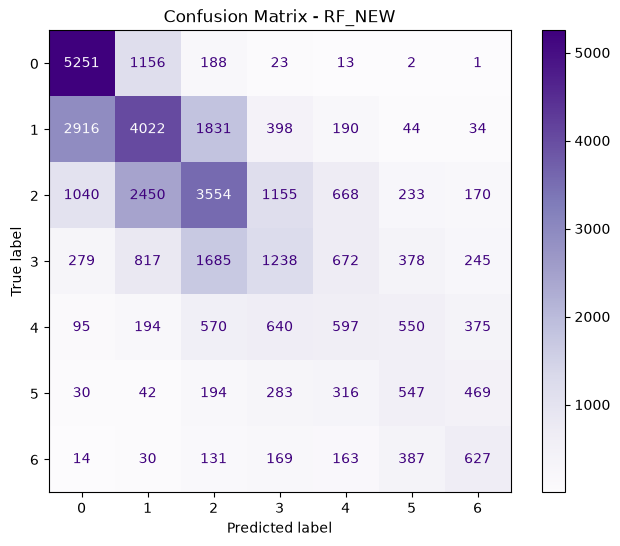

In [13]:
evaluate_model(X_val, y_val, "rf_new", model_dir="../models", preproc_dir="../preprocessing")

<Axes: xlabel='param_clf__max_depth', ylabel='mean_test_score'>

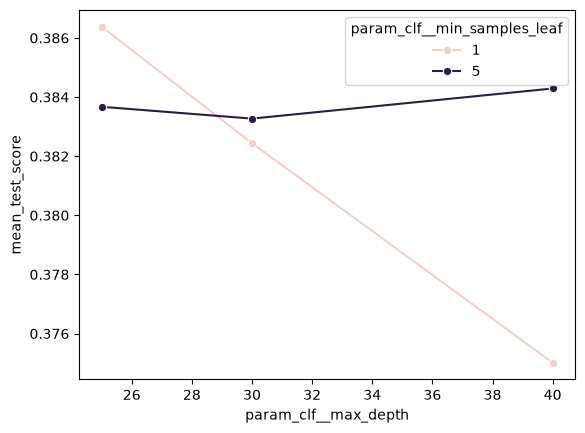

In [14]:
prof = (cv_results_df
        .groupby(['param_clf__max_depth', 'param_clf__min_samples_leaf'])['mean_test_score']
        .max().reset_index())

sns.lineplot(data=prof, x='param_clf__max_depth', y='mean_test_score',
             hue='param_clf__min_samples_leaf', marker='o')

<Axes: xlabel='param_clf__min_samples_leaf', ylabel='param_clf__max_depth'>

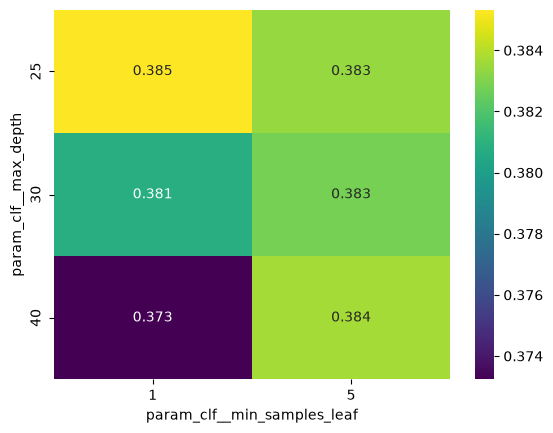

In [15]:
pivot = cv_results_df.pivot_table(
    values='mean_test_score', 
    index='param_clf__max_depth', 
    columns='param_clf__min_samples_leaf', 
    aggfunc='mean'
)
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')